In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

Terdapat 4.096 entri di Data Polis dan 4.627 entri di Data Klaim. Ini artinya satu Nomor Polis bisa memiliki lebih dari satu Claim ID

In [2]:
# data load
df = pd.read_csv('Data_Polis.csv')

print("Data Polis")
display(df.head()) 

print("\ndata info")
print(df.info())

# data load 2
df2 = pd.read_csv('Data_Klaim.csv')

print("\nData Klaim")
display(df2.head())

print("\ndata info")
print(df2.info())

Data Polis


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA
3,POL-0004,M-003,M,20140724,20160811,JAKARTA
4,POL-0005,M-001,F,19810114,20150828,JAKARTA



data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nomor Polis            4096 non-null   object
 1   Plan Code              4096 non-null   object
 2   Gender                 4096 non-null   object
 3   Tanggal Lahir          4096 non-null   int64 
 4   Tanggal Efektif Polis  4096 non-null   int64 
 5   Domisili               4096 non-null   object
dtypes: int64(2), object(4)
memory usage: 192.1+ KB
None

Data Klaim


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore



data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Claim ID                       4627 non-null   object 
 1   Nomor Polis                    4627 non-null   object 
 2   Reimburse/Cashless             4627 non-null   object 
 3   Inpatient/Outpatient           4590 non-null   object 
 4   ICD Diagnosis                  4621 non-null   object 
 5   ICD Description                4621 non-null   object 
 6   Status Klaim                   4627 non-null   object 
 7   Tanggal Pembayaran Klaim       4590 non-null   object 
 8   Tanggal Pasien Masuk RS        4627 non-null   object 
 9   Tanggal Pasien Keluar RS       4627 non-null   object 
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64
 11  Nominal Biaya RS Yang Terjadi  4627 non-null   float64
 12  Lokasi RS                      4620 n


Missing value Data Polis
Series([], dtype: int64)


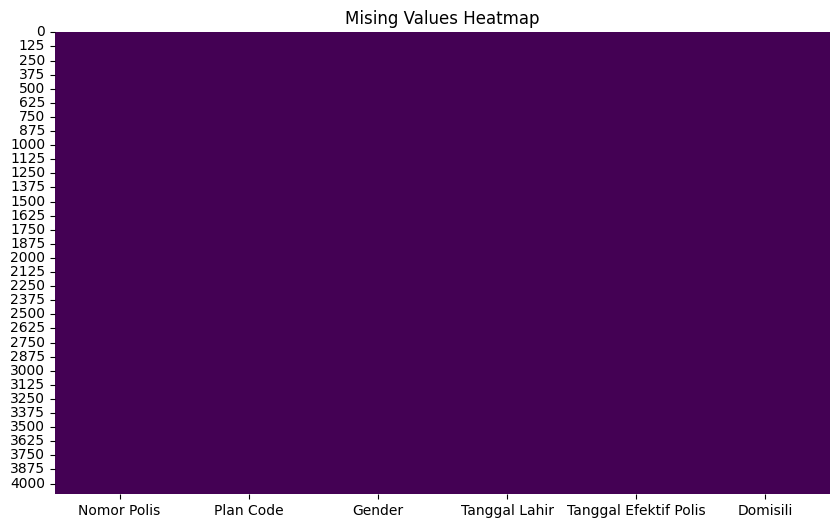


Missing value Data Klaim
Inpatient/Outpatient        37
ICD Diagnosis                6
ICD Description              6
Tanggal Pembayaran Klaim    37
Lokasi RS                    7
dtype: int64


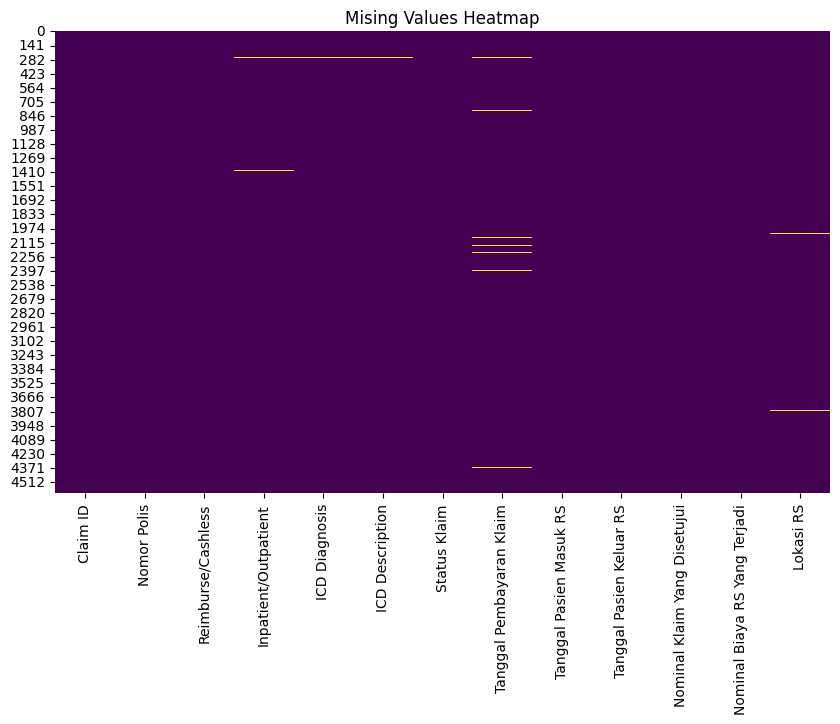

In [3]:
# missing value data polis
print("\nMissing value Data Polis")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mising Values Heatmap')
plt.show()

# missing value data klaim
print("\nMissing value Data Klaim")
missing_values = df2.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df2.isnull(), cbar=False, cmap='viridis')
plt.title('Mising Values Heatmap')
plt.show()

In [4]:
df['Nomor Polis'] = df['Nomor Polis'].str.strip()
df2['Nomor Polis'] = df2['Nomor Polis'].str.strip()

df_final = pd.merge(df, df2, on='Nomor Polis', how='left')

print(f"Jumlah baris df_polis: {len(df)}")
print(f"Jumlah baris df_klaim: {len(df2)}")
print(f"Jumlah baris hasil merge: {len(df_final)}")

display(df_final.head())

Jumlah baris df_polis: 4096
Jumlah baris df_klaim: 4627
Jumlah baris hasil merge: 7513


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,POL-0001,M-003,M,19640811,20140603,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,POL-0002,M-003,M,19710730,20140603,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,POL-0003,M-001,M,19790821,20160808,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia
3,POL-0004,M-003,M,20140724,20160811,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,POL-0005,M-001,F,19810114,20150828,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
cols_to_zero = ['Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi']
df_final[cols_to_zero] = df_final[cols_to_zero].fillna(0)

df_final['is_claim'] = df_final['Claim ID'].notnull().astype(int)

cat_cols = [
    'Claim ID', 'Reimburse/Cashless', 'Inpatient/Outpatient', 
    'ICD Diagnosis', 'ICD Description', 'Lokasi RS', 'Status Klaim'
]

for col in cat_cols:
    df_final.loc[df_final['is_claim'] == 0, col] = 'No Claim'
    df_final[col] = df_final[col].fillna('Unknown')

display(df_final.head())

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,is_claim
0,POL-0001,M-003,M,19640811,20140603,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaN,NaN,NaN,0.0,0.0,No Claim,0
1,POL-0002,M-003,M,19710730,20140603,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaN,NaN,NaN,0.0,0.0,No Claim,0
2,POL-0003,M-001,M,19790821,20160808,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia,1
3,POL-0004,M-003,M,20140724,20160811,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaN,NaN,NaN,0.0,0.0,No Claim,0
4,POL-0005,M-001,F,19810114,20150828,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaN,NaN,NaN,0.0,0.0,No Claim,0


Jumlah outlier ditemukan: 1040 baris
Persentase outlier: 13.84%


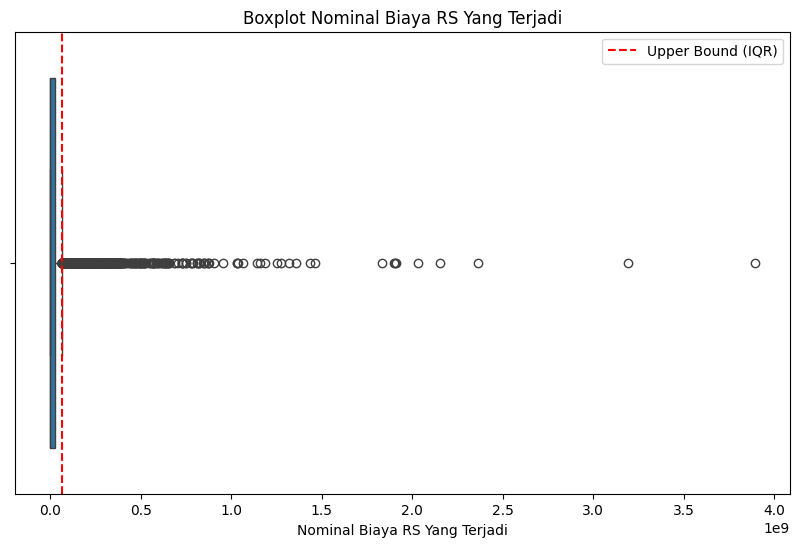

In [6]:
# Menghitung IQR untuk Nominal Biaya RS
Q1 = df_final['Nominal Biaya RS Yang Terjadi'].quantile(0.25)
Q3 = df_final['Nominal Biaya RS Yang Terjadi'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
outliers = df_final[df_final['Nominal Biaya RS Yang Terjadi'] > upper_bound]

print(f"Jumlah outlier ditemukan: {len(outliers)} baris")
print(f"Persentase outlier: {(len(outliers)/len(df_final))*100:.2f}%")


plt.figure(figsize=(10,6))

sns.boxplot(
    x=df_final['Nominal Biaya RS Yang Terjadi']
)

plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound (IQR)')

plt.title('Boxplot Nominal Biaya RS Yang Terjadi')
plt.xlabel('Nominal Biaya RS Yang Terjadi')
plt.legend()

plt.show()

Distribusi memiliki skewness positif yang tinggi. Mengingat porsi outlier mencapai 13.84%, teknik log-transformation (np.log1p) diterapkan untuk menstabilkan varians bagi pemodelan.

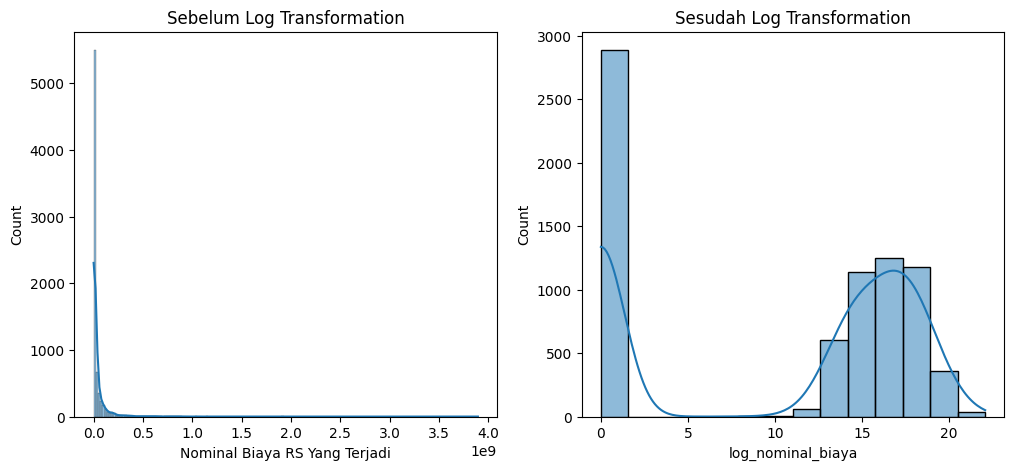

In [7]:
# Log Transformation
df_final['log_nominal_biaya'] = np.log1p(df_final['Nominal Biaya RS Yang Terjadi'])

# Visualisasi
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_final['Nominal Biaya RS Yang Terjadi'], kde=True, ax=ax[0]).set_title('Sebelum Log Transformation')
sns.histplot(df_final['log_nominal_biaya'], kde=True, ax=ax[1]).set_title('Sesudah Log Transformation')
plt.show()

In [8]:
# Sanity check
inkonsisten_biaya = df_final[df_final['Nominal Klaim Yang Disetujui'] > df_final['Nominal Biaya RS Yang Terjadi']]

print(f"Jumlah baris inkonsisten biaya: {len(inkonsisten_biaya)}")

Jumlah baris inkonsisten biaya: 36


In [9]:
# filter data 
df_consistent = df_final[df_final['Nominal Klaim Yang Disetujui'] <= df_final['Nominal Biaya RS Yang Terjadi']]

# rasio median 
ratios = df_consistent[df_consistent['Nominal Biaya RS Yang Terjadi'] > 0]
median_ratio = (ratios['Nominal Klaim Yang Disetujui'] / ratios['Nominal Biaya RS Yang Terjadi']).median()

mask = df_final['Nominal Klaim Yang Disetujui'] > df_final['Nominal Biaya RS Yang Terjadi']
df_final.loc[mask, 'Nominal Klaim Yang Disetujui'] = df_final.loc[mask, 'Nominal Biaya RS Yang Terjadi'] * median_ratio

print(f"Rasio median yang digunakan: {median_ratio:.4f}")

Rasio median yang digunakan: 0.9879


In [10]:
df_final['Tanggal Lahir'] = pd.to_datetime(df_final['Tanggal Lahir'], format='%Y%m%d', errors='coerce')
df_final['Tanggal Efektif Polis'] = pd.to_datetime(df_final['Tanggal Efektif Polis'], format='%Y%m%d', errors='coerce')

df_final['Tanggal Pasien Masuk RS'] = pd.to_datetime(df_final['Tanggal Pasien Masuk RS'], errors='coerce')
df_final['Tanggal Pasien Keluar RS'] = pd.to_datetime(df_final['Tanggal Pasien Keluar RS'], errors='coerce')
df_final['Tanggal Pembayaran Klaim'] = pd.to_datetime(df_final['Tanggal Pembayaran Klaim'], errors='coerce')

display(df_final[df_final['is_claim'] == 1][['Nomor Polis', 'Tanggal Pasien Masuk RS']].head())

,Nomor Polis,Tanggal Pasien Masuk RS
2,POL-0003,2024-09-09
5,POL-0006,2024-08-16
6,POL-0006,2024-10-23
10,POL-0010,2024-01-19
11,POL-0010,2024-01-18



Missing value Data final
Tanggal Pembayaran Klaim    2923
Tanggal Pasien Masuk RS     2886
Tanggal Pasien Keluar RS    2886
dtype: int64


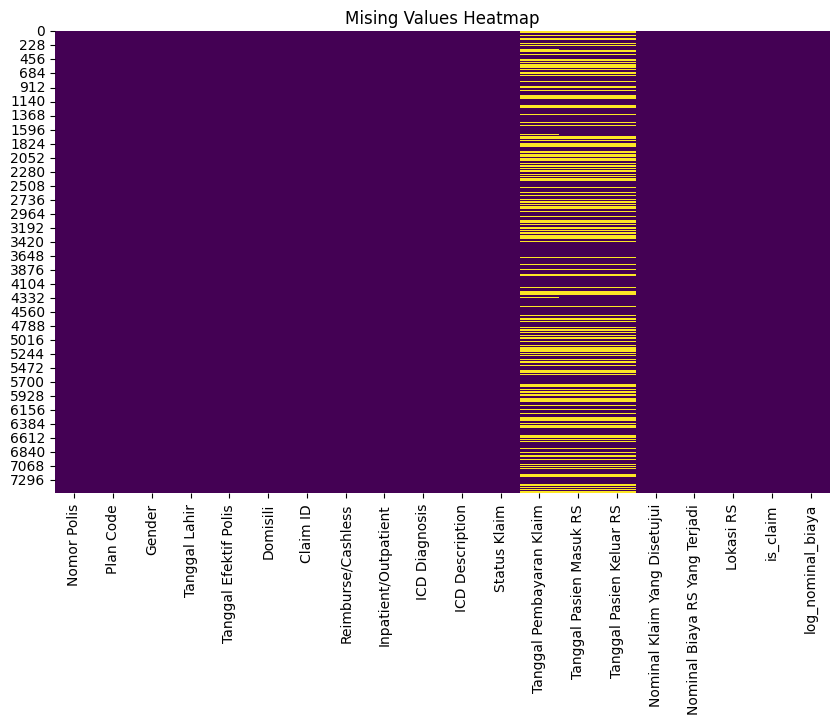

In [11]:
print("\nMissing value Data final")
missing_values = df_final.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df_final.isnull(), cbar=False, cmap='viridis')
plt.title('Mising Values Heatmap')
plt.show()

In [12]:
# 1. Usia Nasabah
ref_date = df_final['Tanggal Pasien Masuk RS'].max()
df_final['Age'] = (df_final['Tanggal Pasien Masuk RS'].fillna(ref_date) - df_final['Tanggal Lahir']).dt.days // 365

# 2. Tenur Polis 
df_final['Policy_Tenure_Days'] = (df_final['Tanggal Pasien Masuk RS'] - df_final['Tanggal Efektif Polis']).dt.days

# 3. Length of Stay 
df_final['Length_of_Stay'] = (df_final['Tanggal Pasien Keluar RS'] - df_final['Tanggal Pasien Masuk RS']).dt.days

display(df_final[['Age', 'Policy_Tenure_Days', 'Length_of_Stay']].describe())

,Age,Policy_Tenure_Days,Length_of_Stay
count,7513.000000,4627.000000,4627.000000
mean,55.343139,3599.079533,1.264102
std,15.308669,639.473687,2.930572
min,6.000000,2200.000000,0.000000
25%,47.000000,3082.000000,0.000000
50%,57.000000,3591.000000,0.000000
75%,67.000000,4155.000000,1.000000
max,90.000000,4942.000000,54.000000


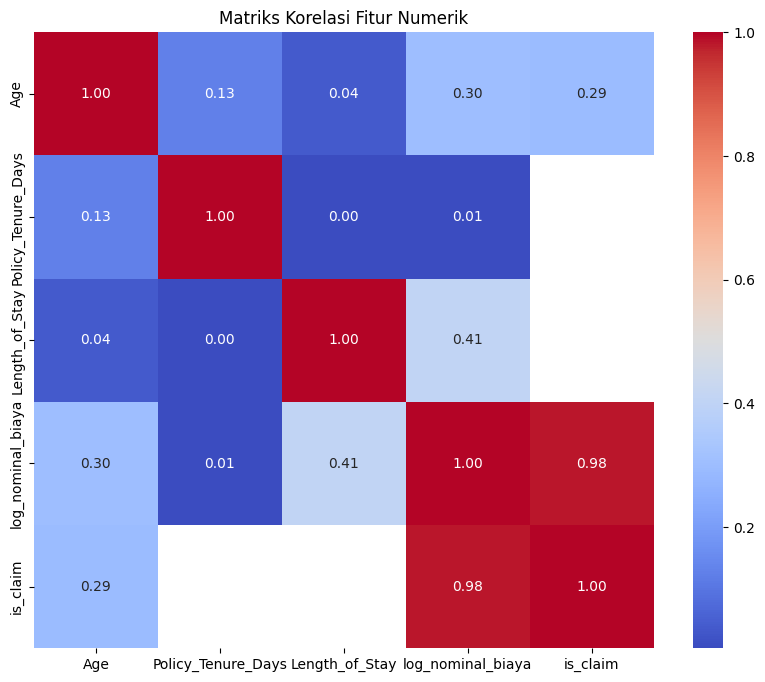

In [13]:
# Menghitung korelasi antar fitur numerik
correlation_matrix = df_final[['Age', 'Policy_Tenure_Days', 'Length_of_Stay', 'log_nominal_biaya', 'is_claim']].corr()

# Visualisasi dengan Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Fitur Numerik')
plt.show()

In [17]:
# Verification Status Kategori unik dan distribusi
print("Kategori unik di Gender:")
print(df_final['Gender'].unique())

print("\nDistribusi tiap kategori:")
print(df_final['Gender'].value_counts())

print("\nKategori unik di Inpatient/Outpatient:")
print(df_final['Inpatient/Outpatient'].unique())

print("\nDistribusi tiap kategori:")
print(df_final['Inpatient/Outpatient'].value_counts())

Kategori unik di Gender:
['M' 'F']

Distribusi tiap kategori:
Gender
M    3778
F    3735
Name: count, dtype: int64

Kategori unik di Inpatient/Outpatient:
['No Claim' 'IP' 'ODS' 'OP' 'ODC' 'Unknown']

Distribusi tiap kategori:
Inpatient/Outpatient
No Claim    2886
IP          2258
OP          1940
ODC          281
ODS          111
Unknown       37
Name: count, dtype: int64


In [19]:
# encoding
gender_map = {'M': 0, 'F': 1}
df_final['Gender_Encoded'] = df_final['Gender'].map(gender_map)

type_map = {
    'No Claim': 0, 
    'OP': 1, 
    'ODC': 2, 
    'ODS': 3, 
    'IP': 4, 
    'Unknown': 5  }
df_final['Type_Encoded'] = df_final['Inpatient/Outpatient'].map(type_map)

print("Hasil Mapping Gender:")
print(df_final[['Gender', 'Gender_Encoded']].value_counts())

print("\nHasil Mapping Inpatient/Outpatient:")
print(df_final[['Inpatient/Outpatient', 'Type_Encoded']].value_counts())

display(df_final[['Gender_Encoded', 'Type_Encoded']].head())

Hasil Mapping Gender:
Gender  Gender_Encoded
M       0                 3778
F       1                 3735
Name: count, dtype: int64

Hasil Mapping Inpatient/Outpatient:
Inpatient/Outpatient  Type_Encoded
No Claim              0               2886
IP                    4               2258
OP                    1               1940
ODC                   2                281
ODS                   3                111
Unknown               5                 37
Name: count, dtype: int64


,Gender_Encoded,Type_Encoded
0,0,0
1,0,0
2,0,4
3,0,0
4,1,0


In [24]:
print (df_final.info())
print (df_final.describe())
print (df_final.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7513 entries, 0 to 7512
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Nomor Polis                    7513 non-null   object        
 1   Plan Code                      7513 non-null   object        
 2   Gender                         7513 non-null   object        
 3   Tanggal Lahir                  7513 non-null   datetime64[ns]
 4   Tanggal Efektif Polis          7513 non-null   datetime64[ns]
 5   Domisili                       7513 non-null   object        
 6   Claim ID                       7513 non-null   object        
 7   Reimburse/Cashless             7513 non-null   object        
 8   Inpatient/Outpatient           7513 non-null   object        
 9   ICD Diagnosis                  7513 non-null   object        
 10  ICD Description                7513 non-null   object        
 11  Status Klaim     